In [42]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table

import sys
sys.path.insert(1, '/Users/nityaravi/Documents/GitHub/RotationCurves/ellipticals/')
from IO_data import extract_data, add_cols, extract_Pipe3d_data
from elliptical_stellar_mass import *
from elliptical_stellar_mass_functions import *

In [45]:
MANGA_FOLDER = '/Users/nityaravi/Documents/Research/RotationCurves/data/manga/'
MAP_FOLDER = MANGA_FOLDER + 'DR17/'
PIPE3D_FOLDER = MANGA_FOLDER +'Pipe3D/'
DRP_FILENAME = MANGA_FOLDER + 'output_files/DR17/CURRENT_MASTER_TABLE/Elliptical_StelVelDispDAPMeanSigma_Mvir_smoothness_lt_2_dipole_vflag_comoving_mratio.fits'
COV_DIR = MANGA_FOLDER + 'elliptical_stellar_mass_cov/'
IMAGE_DIR = MANGA_FOLDER + 'Ellipticals_Images/'


In [34]:
test_gal = '8937-3702'
DRP_table = Table.read(DRP_FILENAME, format='fits')

DRP_index = {}

for i in range(len(DRP_table)):
    gal_ID = DRP_table['plateifu'][i]

    DRP_index[gal_ID] = i

In [46]:
i_DRP = DRP_index[test_gal]
pipe3d_maps = extract_Pipe3d_data(PIPE3D_FOLDER, test_gal, ['sMass'])
if pipe3d_maps is None:
    print('No Pipe3D data for ', test_gal)
    

maps = extract_data(MAP_FOLDER, test_gal, ['Ha', 'flux'])
if maps is None:
    print('No data for ', test_gal)
    
ba = DRP_table['nsa_elpetro_ba'][i_DRP]
phi = DRP_table['nsa_elpetro_phi'][i_DRP]
z = DRP_table['nsa_z'][i_DRP]

data_table = calc_mass_curve(pipe3d_maps['sMass_density'],
                                     pipe3d_maps['sMass_density_err'],
                                     maps['mflux'],
                                     ba,
                                     phi,
                                     z)
best_fit_params = fit_mass_curve(data_table, 
                                         test_gal, 
                                         'mod_hernquist',
                                         COV_DIR=COV_DIR,
                                IMAGE_DIR=IMAGE_DIR)

/Users/nityaravi/Documents/GitHub/RotationCurves/ellipticals/elliptical_plottingFunctions.py:471: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  random_sample = np.random.multivariate_normal(mean=[


/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_5573/151540830.py:10: RuntimeWarning: divide by zero encountered in log10
  ax[0].plot(r, np.log10(modified_hernquist_profile(r, best_fit_params['R_scale'], best_fit_params['M'], best_fit_params['gamma'])),


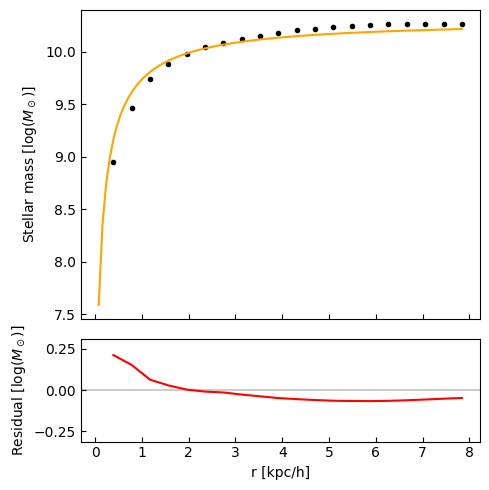

In [67]:
fig, ax = plt.subplots(2,1, sharex=True, height_ratios=[3,1], figsize=(5,5))
#ax[1].plot([0,1],[0,0], color='k',alpha=0.4)
ax[1].axhline(color='k', alpha=0.2)
ax[1].set_xlabel('r [kpc/h]')
ax[0].set_ylabel(r'Stellar mass $[\log(M_\odot)]$')

ax[0].scatter(data_table['radius'], data_table['M_star'], marker='.', color='k')

r = np.linspace(0, np.max(data_table['radius']),100)
ax[0].plot(r, np.log10(modified_hernquist_profile(r, best_fit_params['R_scale'], best_fit_params['M'], best_fit_params['gamma'])),
          color='orange')
res = np.log10(modified_hernquist_profile(data_table['radius'], 
                                          best_fit_params['R_scale'], 
                                          best_fit_params['M'], 
                                          best_fit_params['gamma'])) - data_table['M_star']
ax[1].plot(data_table['radius'], res, color='r')
ax[1].set_ylabel(r'Residual $[\log(M_\odot)]$') 
ax[1].set_ylim(-np.max(np.abs(res))-0.1, np.max(np.abs(res))+0.1)
ax[0].tick_params(direction='in')
ax[1].tick_params(direction='in')
fig.tight_layout()

In [68]:
best_fit_params['M']

20000116575.242424

In [69]:
data_table

radius,M_star,M_star_err
float64,float64,float64
0.3918969061360475,8.950142300013203,0.43754404154067966
0.783793812272095,9.46061303492358,0.716750707956621
1.1756907184081424,9.74216491132228,0.9052057650725956
1.56758762454419,9.884633820025767,1.0269344102009228
1.9594845306802375,9.979037389557991,1.1271073470157302
2.351381436816285,10.03944018030422,1.2091349898120636
2.7432783429523324,10.08010217697608,1.2713900634067294
3.13517524908838,10.120156170764325,1.3320241803714703
3.5270721552244275,10.152330116813303,1.3836214196209644
